# 03 — Thermal noise, Ornstein–Uhlenbeck dynamics, and exact moments

Companion to the equilibrium-noise theory. It derives the Johnson–Nyquist diffusion matrix, verifies the Gibbs stationary covariance, and propagates Gaussian means/covariances exactly.


## Guiding question
How does thermal forcing promote the deterministic RLC equation to an Ornstein–Uhlenbeck process, and which moments can be propagated exactly?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
np.set_printoptions(precision=6, suppress=True)


## 1. Langevin model
For a thermal series resistor,
$$
\mathrm dq=I\,\mathrm dt,\qquad
\mathrm dI=\left[-\frac{q}{LC}-\frac{R}{L}I\right]\mathrm dt
+\frac{\sqrt{2Rk_BT_b}}{L}\,\mathrm dW_t.
$$
Thus $D=BB^T$ has only $D_{II}=2Rk_BT_b/L^2$.


In [2]:
kB=1.380649e-23
L=44.4e-3; C=454e-6; R=27.9; Tb=300.
A=np.array([[0.,1.],[-1/(L*C),-R/L]])
B=np.array([[0.],[np.sqrt(2*R*kB*Tb)/L]])
D=B@B.T
Sigma_b=np.diag([C*kB*Tb,kB*Tb/L])
res=A@Sigma_b+Sigma_b@A.T+D
print('Lyapunov residual norm =',np.linalg.norm(res))
assert np.allclose(res,np.zeros((2,2)),atol=1e-25)
G=np.diag([1/C,L])
E_b=0.5*np.trace(G@Sigma_b)
assert np.isclose(E_b,kB*Tb)
print('equilibrium mean energy / kBT =',E_b/(kB*Tb))


Lyapunov residual norm = 4.930380951504903e-32
equilibrium mean energy / kBT = 1.0000000000000002


## 2. Exact Gaussian propagation
For any Gaussian initial state,
$$
\mu(t)=e^{At}\mu_0,
$$
$$
\Sigma(t)=\Sigma_b+e^{At}(\Sigma_0-\Sigma_b)e^{A^Tt}.
$$
These expressions are exact; no time discretization is needed for the ensemble moments.


exact moment propagation: PASS


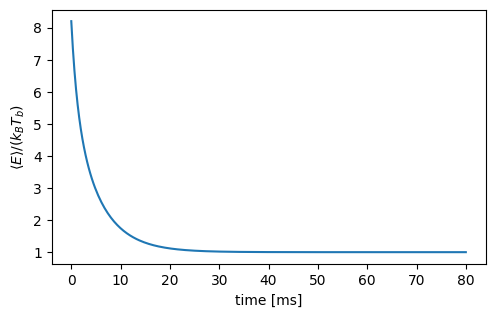

In [3]:
thermal_std=np.sqrt(np.diag(Sigma_b))
mu0=np.array([3.0*thermal_std[0],-2.0*thermal_std[1]])
Sigma0=1.7*Sigma_b
t=np.linspace(0,0.08,250)
mu=[]; Sig=[]; E=[]
for tt in t:
    P=expm(A*tt)
    m=P@mu0
    S=Sigma_b+P@(Sigma0-Sigma_b)@P.T
    mu.append(m); Sig.append(S); E.append(0.5*m@G@m+0.5*np.trace(G@S))
mu=np.array(mu); Sig=np.array(Sig); E=np.array(E)
assert np.all(np.linalg.eigvalsh(Sig)>0)
print('exact moment propagation: PASS')
fig,ax=plt.subplots(figsize=(5.6,3.3)); ax.plot(1e3*t,E/(kB*Tb)); ax.set(xlabel='time [ms]',ylabel=r'$\langle E\rangle/(k_BT_b)$'); plt.show()


## 3. Exact finite-step OU update
The discrete exact propagator is
$$
X_{n+1}=\Phi X_n+\eta_n,\qquad \Phi=e^{A\Delta t},
$$
with $\eta_n\sim\mathcal N(0,Q)$ and
$$
Q=\Sigma_b-\Phi\Sigma_b\Phi^T.
$$
Notebook 07 uses this formula for sampling and numerical certification.


## Reader exploration
1. Change the series resistance while remaining overdamped and verify the stationary Lyapunov equation again. 2. Change the sampling interval in the exact finite-step update and confirm that sampled-time moments remain exact.
